# Point Cloud Classification with PointNet

 
**Dataset:** ModelNet10 — 10 classes of 3D CAD models (bathtub, bed, chair, desk, dresser, monitor, night_stand, sofa, table, toilet)


## 1. Environment Check

We confirm the Python version, PyTorch version, and the available hardware accelerator (CUDA for NVIDIA GPUs, MPS for Apple Silicon, or CPU fallback). The `device` variable detected here will be used throughout the project to move tensors onto the GPU.

In [1]:
import sys
import platform
import torch

print("Python version :", sys.version.split()[0])
print("Platform       :", platform.platform())
print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version   :", torch.version.cuda)
    print("GPU device     :", torch.cuda.get_device_name(0))
    print("GPU count      :", torch.cuda.device_count())
elif torch.backends.mps.is_available():
    print("Apple MPS      : available (Apple Silicon GPU)")
else:
    print("No GPU detected -> will fall back to CPU")

Python version : 3.13.9
Platform       : macOS-26.4.1-arm64-arm-64bit-Mach-O
PyTorch version: 2.12.0
CUDA available : False
Apple MPS      : available (Apple Silicon GPU)


## 2. Library Imports and Reproducibility

We import the libraries used in this notebook and set random seeds so that runs are reproducible. The `device` variable is the single source of truth for where tensors live during training.

In [2]:
import os
import glob
import random
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Choose device once and reuse everywhere
device = (
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"Using device: {device}")

Using device: mps


## 3. Downloading the ModelNet10 Dataset

ModelNet10 contains 10 classes of CAD-modelled household objects (bathtub, bed, chair, desk, dresser, monitor, night_stand, sofa, table, toilet). It's the smaller cousin of ModelNet40

In [3]:
import urllib.request
import zipfile

DATA_URL = "http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip"

# Locate the project root no matter where the notebook is launched from
cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.dirname(cwd) if os.path.basename(cwd) == "notebooks" else cwd

DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
ZIP_PATH  = os.path.join(DATA_ROOT, "ModelNet10.zip")
DATA_DIR  = os.path.join(DATA_ROOT, "ModelNet10")

os.makedirs(DATA_ROOT, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Data root   : {DATA_ROOT}")

if not os.path.isdir(DATA_DIR):
    if not os.path.isfile(ZIP_PATH):
        print(f"\nDownloading ModelNet10 from {DATA_URL} ...")
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
        print("Download complete.")
    print(f"Extracting to {DATA_ROOT} ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_ROOT)
    print("Extraction complete.")
else:
    print(f"\nDataset already present at {DATA_DIR} - skipping download.")

print(f"\nDATA_DIR = {DATA_DIR}")
print(f"Exists   : {os.path.isdir(DATA_DIR)}")

Project root: /Users/dosvatsky/3D Object Detection
Data root   : /Users/dosvatsky/3D Object Detection/data

Download complete.
Extracting to /Users/dosvatsky/3D Object Detection/data ...
Extraction complete.

DATA_DIR = /Users/dosvatsky/3D Object Detection/data/ModelNet10
Exists   : True


## 4. Inspect the Dataset Structure



In [3]:
# Each class is a sub-folder (10 of them);
class_folders = sorted(
    f for f in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, f))
)
print(f"Number of classes: {len(class_folders)}")
print("Classes:", class_folders)

print("\nFile counts per class:")
print(f"{'class':<14}{'train':>8}{'test':>8}")
print("-" * 30)
total_train = total_test = 0
for c in class_folders:
    n_train = len(glob.glob(os.path.join(DATA_DIR, c, "train", "*.off")))
    n_test  = len(glob.glob(os.path.join(DATA_DIR, c, "test",  "*.off")))
    total_train += n_train
    total_test  += n_test
    print(f"{c:<14}{n_train:>8}{n_test:>8}")
print("-" * 30)
print(f"{'TOTAL':<14}{total_train:>8}{total_test:>8}")

Number of classes: 10
Classes: ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']

File counts per class:
class            train    test
------------------------------
bathtub            106      50
bed                515     100
chair              889     100
desk               200      86
dresser            200      86
monitor            465     100
night_stand        200      86
sofa               680     100
table              392     100
toilet             344     100
------------------------------
TOTAL             3991     908


## 5. Sanity Check


In [4]:
import os
import glob
import numpy as np
import torch
import trimesh
from torch.utils.data import Dataset

# ---- Resolve paths defensively (works whether launched from project root or notebooks/) ----
_cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "ModelNet10")

# ---- Fixed class list and label mapping (alphabetical => deterministic across runs) ----
CLASSES = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

print("Class -> index mapping (used as labels):")
for c, i in CLASS_TO_IDX.items():
    print(f"  {i:>2}  {c}")


# ---- Dataset class ----
class ModelNet10Dataset(Dataset):
    """PyTorch Dataset for ModelNet10.

    Walks data/ModelNet10/<class>/<split>/*.off, loads each mesh with trimesh,
    samples `num_points` points uniformly from the mesh surface, normalizes the
    cloud to a unit sphere centered at the origin, and returns
    (points_tensor [num_points, 3], label_int).
    """

    def __init__(self, root, split="train", num_points=1024):
        assert split in {"train", "test"}, "split must be 'train' or 'test'"
        self.root = root
        self.split = split
        self.num_points = num_points

        # Collect (filepath, label) pairs once, sorted for reproducibility
        self.samples = []
        for class_name in CLASSES:
            class_dir = os.path.join(root, class_name, split)
            for fp in sorted(glob.glob(os.path.join(class_dir, "*.off"))):
                self.samples.append((fp, CLASS_TO_IDX[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fp, label = self.samples[idx]

        # Load mesh and sample points uniformly from the surface
        mesh = trimesh.load(fp, force="mesh")
        points, _ = trimesh.sample.sample_surface(mesh, self.num_points)
        points = np.asarray(points, dtype=np.float32)

        # Normalize: center to origin, scale so max radius == 1 (unit sphere)
        points = points - points.mean(axis=0, keepdims=True)
        scale = np.max(np.linalg.norm(points, axis=1))
        points = points / scale

        return torch.from_numpy(points), label


# ---- Instantiate train + test sets ----
train_ds = ModelNet10Dataset(DATA_DIR, split="train", num_points=1024)
test_ds  = ModelNet10Dataset(DATA_DIR, split="test",  num_points=1024)

print(f"\nTrain samples: {len(train_ds)}")
print(f"Test samples : {len(test_ds)}")

# ---- Load one sample as a sanity check ----
points, label = train_ds[0]
print(f"\n--- Sanity check on train_ds[0] ---")
print(f"  points.shape       : {tuple(points.shape)}     (expected (1024, 3))")
print(f"  points.dtype       : {points.dtype}            (expected torch.float32)")
print(f"  label              : {label}  ({IDX_TO_CLASS[label]})")
print(f"  centered? mean     : {points.mean(0).numpy().round(4)}  (expected ~[0, 0, 0])")

print(f"  unit-sphere? max r : {points.norm(dim=1).max().item():.4f}  (expected 1.0000)")

Class -> index mapping (used as labels):
   0  bathtub
   1  bed
   2  chair
   3  desk
   4  dresser
   5  monitor
   6  night_stand
   7  sofa
   8  table
   9  toilet

Train samples: 3991
Test samples : 908

--- Sanity check on train_ds[0] ---
  points.shape       : (1024, 3)     (expected (1024, 3))
  points.dtype       : torch.float32            (expected torch.float32)
  label              : 0  (bathtub)
  centered? mean     : [-0. -0.  0.]  (expected ~[0, 0, 0])
  unit-sphere? max r : 1.0000  (expected 1.0000)


## Wrap the Dataset in a DataLoader and visualize samples


--- One training batch ---
  points_batch.shape : (32, 1024, 3)     (expected (32, 1024, 3))
  points_batch.dtype : torch.float32
  labels_batch.shape : (32,)              (expected (32,))
  labels_batch.dtype : torch.int64
  labels in batch    : [3, 3, 2, 4, 5, 4, 0, 2, 9, 0, 0, 8, 8, 8, 6, 8, 6, 5, 3, 7, 2, 7, 2, 5, 6, 5, 1, 6, 2, 1, 1, 8]
  unique classes     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  (10 of 10)
  load time          : 1.18s for 32 samples (37 ms/sample)


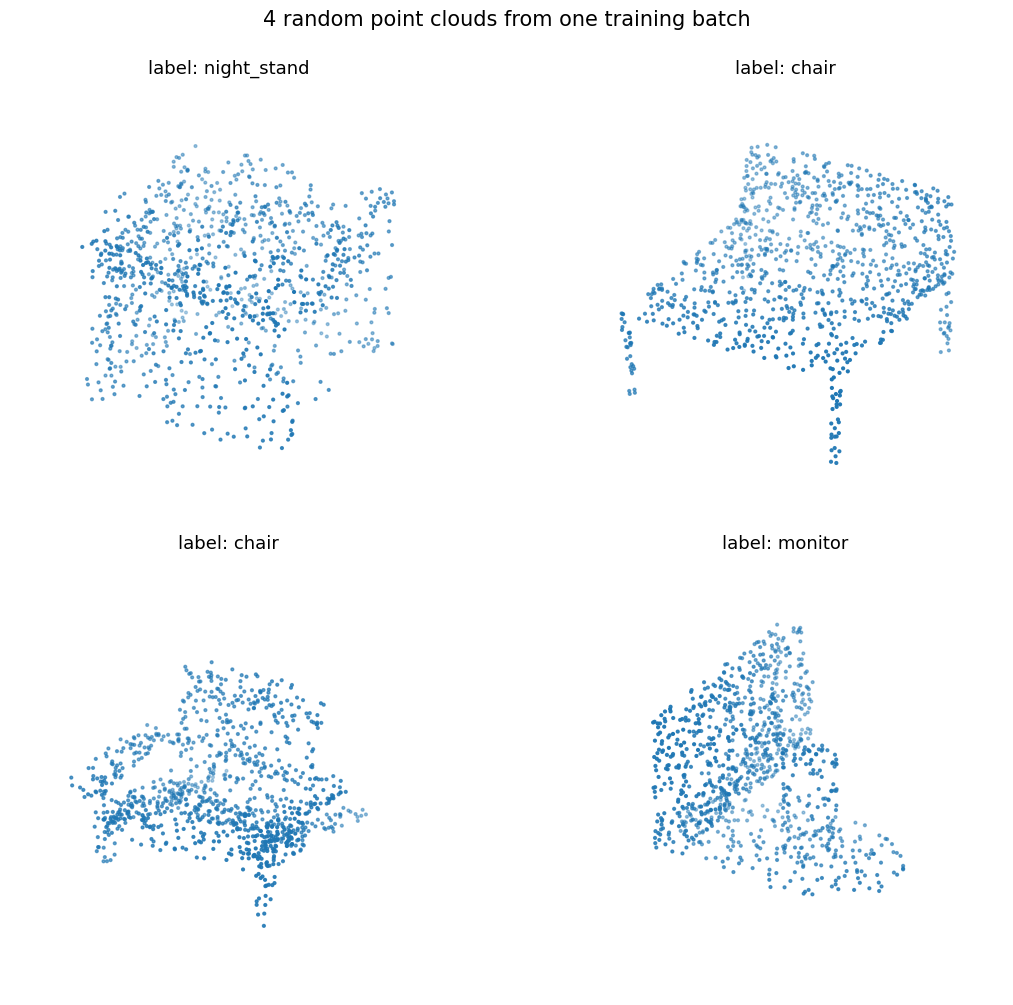

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers '3d' projection)
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# num_workers=0 on macOS/MPS — trimesh + multiprocessing is unreliable here.
# We'll revisit this if data loading becomes the training bottleneck.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ---- Pull one batch and inspect ----
start = time.time()
points_batch, labels_batch = next(iter(train_loader))
elapsed = time.time() - start

print(f"--- One training batch ---")
print(f"  points_batch.shape : {tuple(points_batch.shape)}     (expected ({BATCH_SIZE}, 1024, 3))")
print(f"  points_batch.dtype : {points_batch.dtype}")
print(f"  labels_batch.shape : {tuple(labels_batch.shape)}              (expected ({BATCH_SIZE},))")
print(f"  labels_batch.dtype : {labels_batch.dtype}")
print(f"  labels in batch    : {labels_batch.tolist()}")
print(f"  unique classes     : {sorted(set(labels_batch.tolist()))}  ({len(set(labels_batch.tolist()))} of 10)")
print(f"  load time          : {elapsed:.2f}s for {BATCH_SIZE} samples ({elapsed/BATCH_SIZE*1000:.0f} ms/sample)")

# ---- Plot 4 random samples from the batch ----
rng = np.random.default_rng(42)  # fixed seed so the figure is reproducible
plot_indices = rng.choice(BATCH_SIZE, size=4, replace=False)

fig = plt.figure(figsize=(12, 10))
for plot_i, batch_i in enumerate(plot_indices):
    pts = points_batch[batch_i].numpy()
    cls = IDX_TO_CLASS[labels_batch[batch_i].item()]
    ax = fig.add_subplot(2, 2, plot_i + 1, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=4)
    ax.set_title(f"label: {cls}", fontsize=13)
    ax.set_axis_off()
plt.suptitle("4 random point clouds from one training batch", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

## Define PointNet v1 (minimal, no T-Net)

We build the smallest version of PointNet first: per-point shared MLPs to lift each xyz coordinate into a high-dimensional feature, a global max-pool to collapse all points into a single fixed-size descriptor of the shape, then fully-connected layers to produce class logits


In [6]:
import torch
import torch.nn as nn


class PointNetV1(nn.Module):
    """Minimal PointNet classifier — no T-Net, no feature transform.

    Architecture:
        Input            (B, N, 3)
        → permute to     (B, 3, N)
        → shared MLP (64, 64, 64, 128, 1024)  — Conv1d with kernel_size=1
        → global max-pool over N              → (B, 1024)
        → classifier (512, 256, num_classes)  → (B, num_classes)
    """

    def __init__(self, num_classes=10):
        super().__init__()

        # Per-point shared MLP. Implemented as Conv1d with kernel_size=1
        # over the N dim, which is mathematically identical to a Linear layer
        # applied independently to every point with shared weights.
        self.shared_mlp = nn.Sequential(
            nn.Conv1d(3,   64,   kernel_size=1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  64,   kernel_size=1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  64,   kernel_size=1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  128,  kernel_size=1), nn.BatchNorm1d(128),  nn.ReLU(),
            nn.Conv1d(128, 1024, kernel_size=1), nn.BatchNorm1d(1024), nn.ReLU(),
        )

        # Classifier head — operates on the (B, 1024) globally-pooled feature
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256,  num_classes),
        )

    def forward(self, x):
        # x: (B, N, 3) -> permute to (B, 3, N) so Conv1d sees 3 input channels
        x = x.transpose(1, 2)         # (B, 3, N)
        x = self.shared_mlp(x)        # (B, 1024, N)
        x = torch.max(x, dim=2)[0]    # (B, 1024)  — permutation-invariant pool
        x = self.classifier(x)        # (B, num_classes)
        return x


# ---- Instantiate and inspect ----
model = PointNetV1(num_classes=10)

n_mlp        = sum(p.numel() for p in model.shared_mlp.parameters())
n_classifier = sum(p.numel() for p in model.classifier.parameters())
n_total      = sum(p.numel() for p in model.parameters())

print("Model: PointNet v1 (minimal — no T-Net, no feature transform, no regularizer)\n")
print("Parameter count by block:")
print(f"  shared per-point MLP : {n_mlp:>9,}")
print(f"  classifier head      : {n_classifier:>9,}")
print(f"  {'-'*36}")
print(f"  total                : {n_total:>9,}")
print()
print(model)

Model: PointNet v1 (minimal — no T-Net, no feature transform, no regularizer)

Parameter count by block:
  shared per-point MLP :   151,680
  classifier head      :   660,234
  ------------------------------------
  total                :   811,914

PointNetV1(
  (shared_mlp): Sequential(
    (0): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
    (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(128, 1

## Pre-cacheing point clouds

In [8]:
from tqdm.auto import tqdm

CACHE_DIR = os.path.join(PROJECT_ROOT, "data", "cache_1024pts")
os.makedirs(CACHE_DIR, exist_ok=True)

def precache_split(dataset, split_name):
    """Sample every mesh once, save (points, labels) as .npz."""
    cache_path = os.path.join(CACHE_DIR, f"{split_name}.npz")
    if os.path.exists(cache_path):
        print(f"Cache for '{split_name}' already exists at {cache_path} — skipping.")
        return cache_path

    n = len(dataset)
    all_points = np.zeros((n, dataset.num_points, 3), dtype=np.float32)
    all_labels = np.zeros(n, dtype=np.int64)

    for i in tqdm(range(n), desc=f"Caching {split_name}"):
        pts, lbl = dataset[i]
        all_points[i] = pts.numpy()
        all_labels[i] = lbl

    np.savez(cache_path, points=all_points, labels=all_labels)
    size_mb = os.path.getsize(cache_path) / 1024**2
    print(f"Saved '{split_name}' cache: {all_points.shape}, {size_mb:.1f} MB")
    return cache_path

train_cache_path = precache_split(train_ds, "train")
test_cache_path  = precache_split(test_ds,  "test")


class CachedModelNet10(Dataset):
    """Reads pre-sampled point clouds from .npz — orders of magnitude faster than the trimesh-based Dataset."""
    def __init__(self, cache_path):
        data = np.load(cache_path)
        self.points = data["points"]   # (n, 1024, 3) float32
        self.labels = data["labels"]   # (n,) int64

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.points[idx]), int(self.labels[idx])


# Swap in the cached datasets + drop_last on train to keep BN happy
train_cached = CachedModelNet10(train_cache_path)
test_cached  = CachedModelNet10(test_cache_path)

train_loader = DataLoader(train_cached, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
test_loader  = DataLoader(test_cached,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ---- Timing comparison ----
start = time.time()
pts, lbls = next(iter(train_loader))
print(f"\nNew batch-load time: {(time.time()-start)*1000:.1f} ms  "
      f"(was ~3000 ms with on-the-fly trimesh sampling)")
print(f"Train batches/epoch: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Caching train:   0%|          | 0/3991 [00:00<?, ?it/s]

Saved 'train' cache: (3991, 1024, 3), 46.8 MB


Caching test:   0%|          | 0/908 [00:00<?, ?it/s]

Saved 'test' cache: (908, 1024, 3), 10.6 MB

New batch-load time: 0.9 ms  (was ~3000 ms with on-the-fly trimesh sampling)
Train batches/epoch: 124  |  Test batches: 29


## Running the 20-epoch training loop

Training PointNet v1 — 20 epochs on mps
Train: 3991 samples  |  Test: 908 samples

epoch   train_loss   train_acc    val_acc     time
-------------------------------------------------------
    1       0.4247      0.8606     0.8502    24.6s  *
    2       0.2138      0.9252     0.8601    26.5s  *
    3       0.1847      0.9350     0.7919    28.9s
    4       0.1673      0.9413     0.8436    24.2s
    5       0.1608      0.9420     0.8888    24.9s  *
    6       0.1394      0.9491     0.8689    25.7s
    7       0.1274      0.9551     0.8744    25.5s
    8       0.1286      0.9524     0.8359    26.6s
    9       0.0943      0.9657     0.8899    25.1s  *
   10       0.1118      0.9561     0.9097    24.3s  *
   11       0.0985      0.9630     0.8910    24.5s
   12       0.0982      0.9647     0.8855    24.5s
   13       0.0759      0.9685     0.8822    24.2s
   14       0.0846      0.9677     0.8711    24.2s
   15       0.0876      0.9652     0.8899    24.2s
   16       0.0832      0.9680

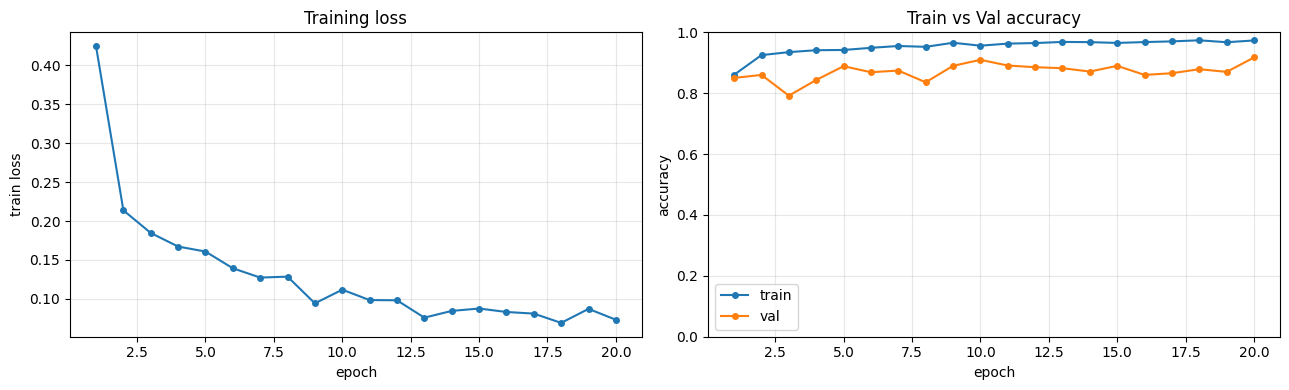

In [9]:
import torch.nn.functional as F

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
best_path = os.path.join(CHECKPOINT_DIR, "pointnet_v1_best.pt")

# Fresh model + optimizer
model = PointNetV1(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 20
history = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

print(f"Training PointNet v1 — {NUM_EPOCHS} epochs on {device}")
print(f"Train: {len(train_cached)} samples  |  Test: {len(test_cached)} samples\n")
print(f"{'epoch':>5}  {'train_loss':>11}  {'train_acc':>10}  {'val_acc':>9}  {'time':>7}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ---- Train ----
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for pts, lbls in train_loader:
        pts, lbls = pts.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(pts)
        loss = F.cross_entropy(logits, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * pts.size(0)
        correct  += (logits.argmax(1) == lbls).sum().item()
        total    += pts.size(0)
    train_loss = loss_sum / total
    train_acc  = correct  / total

    # ---- Validate ----
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for pts, lbls in test_loader:
            pts, lbls = pts.to(device), lbls.to(device)
            val_correct += (model(pts).argmax(1) == lbls).sum().item()
            val_total   += pts.size(0)
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        flag = "  *"

    print(f"{epoch:>5}  {train_loss:>11.4f}  {train_acc:>10.4f}  {val_acc:>9.4f}  {time.time()-t0:>6.1f}s{flag}")

print(f"\nBest val_acc: {best_val_acc:.4f}  (checkpoint: {best_path})")

# ---- Plot loss + accuracy curves ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, NUM_EPOCHS + 1)
ax1.plot(ep, history["train_loss"], "-o", markersize=4)
ax1.set(xlabel="epoch", ylabel="train loss", title="Training loss")
ax1.grid(alpha=0.3)
ax2.plot(ep, history["train_acc"], "-o", markersize=4, label="train")
ax2.plot(ep, history["val_acc"],   "-o", markersize=4, label="val")
ax2.set(xlabel="epoch", ylabel="accuracy", title="Train vs Val accuracy", ylim=(0, 1))
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Per-class evaluation of PointNet v1


Loaded checkpoint: /Users/dosvatsky/3D Object Detection/checkpoints/pointnet_v1_best.pt

Inference complete on 908 test samples.

OVERALL METRICS
  Accuracy     : 0.9174
  Macro F1     : 0.9125   (unweighted mean across classes)
  Weighted F1  : 0.9183   (weighted by class support)

PER-CLASS METRICS
              precision    recall  f1-score   support

     bathtub     0.7903    0.9800    0.8750        50
         bed     0.9659    0.8500    0.9043       100
       chair     0.9900    0.9900    0.9900       100
        desk     0.9221    0.8256    0.8712        86
     dresser     0.8276    0.8372    0.8324        86
     monitor     1.0000    0.9600    0.9796       100
 night_stand     0.7634    0.8256    0.7933        86
        sofa     1.0000    0.9800    0.9899       100
       table     0.8636    0.9500    0.9048       100
      toilet     1.0000    0.9700    0.9848       100

    accuracy                         0.9174       908
   macro avg     0.9123    0.9168    0.9125     

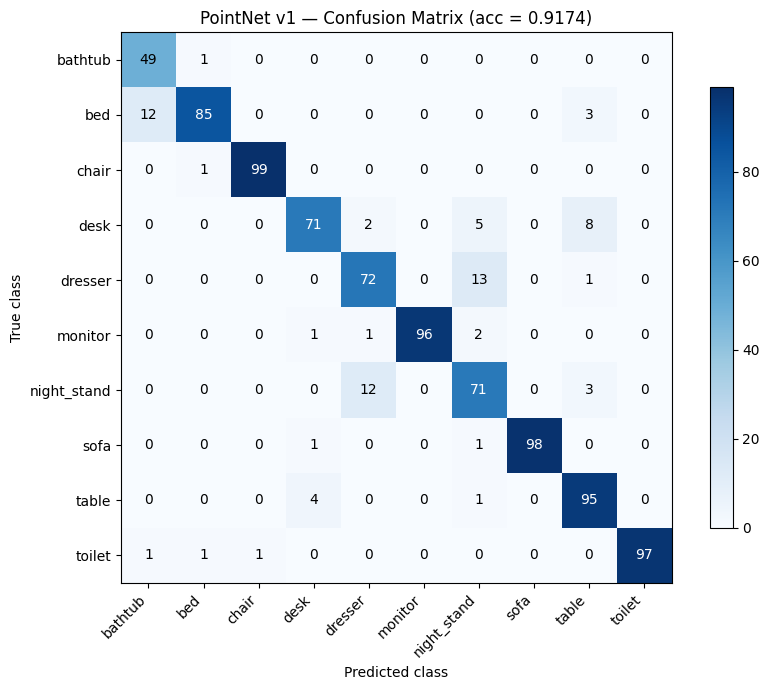


TOP 5 CONFUSION PAIRS (off-diagonal)
        dresser  →  night_stand    : 13 samples misclassified
    night_stand  →  dresser        : 12 samples misclassified
            bed  →  bathtub        : 12 samples misclassified
           desk  →  table          : 8 samples misclassified
           desk  →  night_stand    : 5 samples misclassified


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# ---- Load best checkpoint ----
model = PointNetV1(num_classes=10).to(device)
model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
model.eval()
print(f"Loaded checkpoint: {best_path}\n")

# ---- Run inference on full test set ----
all_preds, all_labels = [], []
with torch.no_grad():
    for pts, lbls in test_loader:
        pts = pts.to(device)
        preds = model(pts).argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(lbls.numpy())
all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
print(f"Inference complete on {len(all_labels)} test samples.\n")

# ---- 1. Overall metrics ----
acc         = accuracy_score(all_labels, all_preds)
macro_f1    = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("=" * 55)
print("OVERALL METRICS")
print("=" * 55)
print(f"  Accuracy     : {acc:.4f}")
print(f"  Macro F1     : {macro_f1:.4f}   (unweighted mean across classes)")
print(f"  Weighted F1  : {weighted_f1:.4f}   (weighted by class support)")

# ---- 2. Per-class metrics table ----
print("\n" + "=" * 55)
print("PER-CLASS METRICS")
print("=" * 55)
print(classification_report(all_labels, all_preds,
                            target_names=CLASSES, digits=4))

# ---- 3. Class coverage check ----
predicted_classes = set(all_preds.tolist())
missing = set(range(10)) - predicted_classes

print("=" * 55)
print("CLASS COVERAGE CHECK")
print("=" * 55)
print(f"  Distinct classes predicted: {len(predicted_classes)}/10")
if missing:
    print(f"  MISSING (never predicted): {[CLASSES[i] for i in sorted(missing)]}")
    print(f"  GATE FAILED — class collapse. Do not advance until fixed.")
else:
    print(f"  GATE PASSED — every class predicted at least once.")

print(f"\n  Prediction count vs true count per class:")
print(f"  {'class':<14}{'predicted':>11}{'true':>8}{'delta':>8}")
print(f"  {'-'*40}")
for i, c in enumerate(CLASSES):
    n_pred = int((all_preds  == i).sum())
    n_true = int((all_labels == i).sum())
    print(f"  {c:<14}{n_pred:>11}{n_true:>8}{n_pred - n_true:>+8}")

# ---- 4. Confusion matrix heatmap ----
cm = confusion_matrix(all_labels, all_preds, labels=list(range(10)))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"PointNet v1 — Confusion Matrix (acc = {acc:.4f})")

for i in range(10):
    for j in range(10):
        v = cm[i, j]
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=10)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# ---- Top confusion pairs (for the writeup) ----
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
print("\n" + "=" * 55)
print("TOP 5 CONFUSION PAIRS (off-diagonal)")
print("=" * 55)
flat = [(cm_off[i, j], CLASSES[i], CLASSES[j]) for i in range(10) for j in range(10)]
flat.sort(reverse=True)
for count, true_c, pred_c in flat[:5]:
    if count == 0: break
    print(f"  {true_c:>13}  →  {pred_c:<13}  : {count} samples misclassified")

## Optimizing PointNet v1 

In [11]:
class AugmentedModelNet10(Dataset):
    """Cached ModelNet10 with optional on-the-fly augmentation.

    augment=True applies (in order, per __getitem__ call):
      1. random rotation around the z-axis, angle ~ Uniform[0, 2pi)
      2. per-point Gaussian jitter, sigma=0.02, clipped to +/-0.05
    Test set should always use augment=False so eval numbers are comparable.
    """
    def __init__(self, cache_path, augment=False, jitter_sigma=0.02, jitter_clip=0.05):
        data = np.load(cache_path)
        self.points = data["points"]   # (n, 1024, 3) float32
        self.labels = data["labels"]   # (n,) int64
        self.augment = augment
        self.jitter_sigma = jitter_sigma
        self.jitter_clip = jitter_clip

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        pts = self.points[idx].copy()  # critical: copy so we don't mutate cache
        if self.augment:
            # 1. Random rotation around z (vertical) axis
            theta = np.random.uniform(0, 2 * np.pi)
            c, s = np.cos(theta), np.sin(theta)
            R = np.array([[ c, -s, 0],
                          [ s,  c, 0],
                          [ 0,  0, 1]], dtype=np.float32)
            pts = pts @ R.T
            # 2. Per-point Gaussian jitter, clipped
            jitter = np.random.normal(0, self.jitter_sigma, pts.shape).astype(np.float32)
            jitter = np.clip(jitter, -self.jitter_clip, self.jitter_clip)
            pts = pts + jitter
        return torch.from_numpy(pts), int(self.labels[idx])


# Build new loaders: augmented train, clean test
train_aug = AugmentedModelNet10(train_cache_path, augment=True)
test_clean = AugmentedModelNet10(test_cache_path,  augment=False)

train_loader = DataLoader(train_aug,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
test_loader  = DataLoader(test_clean, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train (augmented): {len(train_aug)} samples, {len(train_loader)} batches")
print(f"Test  (clean)    : {len(test_clean)} samples, {len(test_loader)} batches")

Train (augmented): 3991 samples, 124 batches
Test  (clean)    : 908 samples, 29 batches


## Visualization of what Augumentation Does

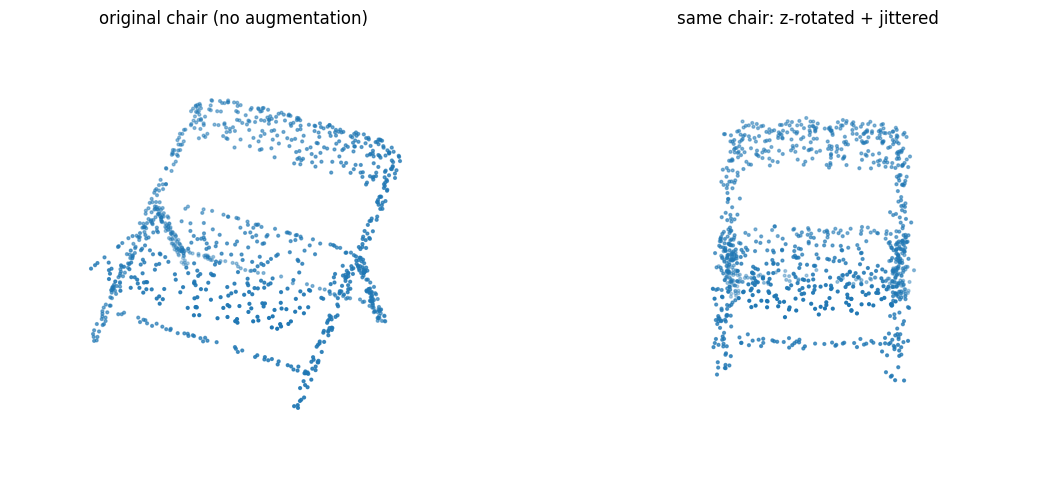

In [13]:
# Pick a chair from training set for the demo (label 2 = chair)
chair_idx = int(np.where(train_aug.labels == 2)[0][0])

# Original (augmentation off)
pts_orig = train_aug.points[chair_idx].copy()
# Augmented — make a temp instance with augment=True
np.random.seed(7)
pts_augd, _ = train_aug[chair_idx]
pts_augd = pts_augd.numpy()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(pts_orig[:, 0], pts_orig[:, 1], pts_orig[:, 2], s=4)
ax1.set_title("original chair (no augmentation)")
ax1.set_axis_off()

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(pts_augd[:, 0], pts_augd[:, 1], pts_augd[:, 2], s=4)
ax2.set_title("same chair: z-rotated + jittered")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

## Retraining PointNet v1 with augmented training data

Training PointNet v1 + augmentation — 20 epochs on mps
Augmentations: random z-rotation + per-point jitter (sigma=0.02, clip=0.05)

epoch   train_loss   train_acc    val_acc     time
-------------------------------------------------------
    1       0.7184      0.7548     0.7379    32.1s  *
    2       0.4416      0.8369     0.7302    26.3s
    3       0.3778      0.8674     0.8128    25.9s  *
    4       0.3271      0.8866     0.8161    24.3s  *
    5       0.3285      0.8843     0.8018    23.4s
    6       0.2840      0.8969     0.8590    24.9s  *
    7       0.2761      0.8969     0.8579    24.8s
    8       0.2524      0.9118     0.8436    23.9s
    9       0.2388      0.9128     0.8117    24.3s
   10       0.2438      0.9110     0.8392    24.2s
   11       0.2295      0.9204     0.8689    25.0s  *
   12       0.2290      0.9105     0.8800    24.0s  *
   13       0.2078      0.9234     0.8326    24.0s
   14       0.2155      0.9211     0.8844    24.2s  *
   15       0.1872      0.

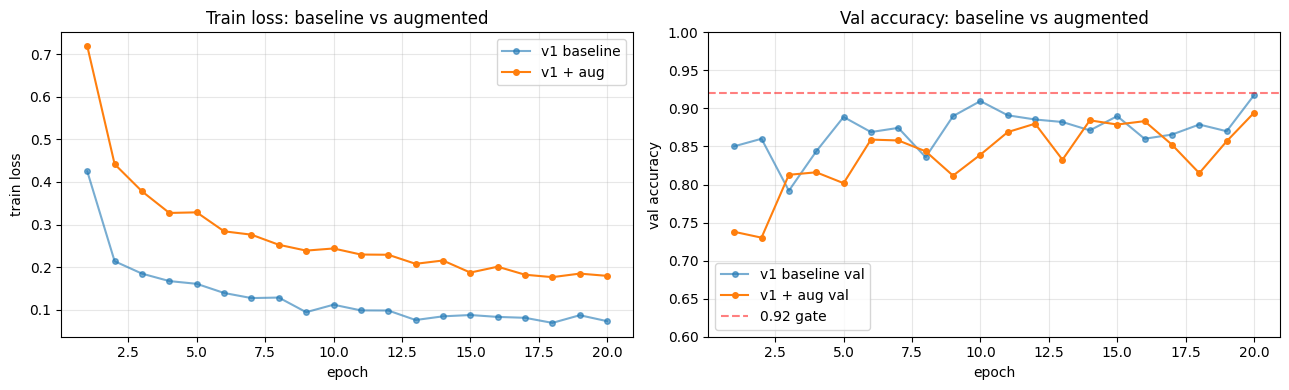

In [14]:
# New checkpoint name — keep the v1 baseline untouched
best_path_aug = os.path.join(CHECKPOINT_DIR, "pointnet_v1_aug_best.pt")

# Fresh model + optimizer (don't continue from baseline weights)
model = PointNetV1(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 20
history_aug = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc_aug = 0.0

print(f"Training PointNet v1 + augmentation — {NUM_EPOCHS} epochs on {device}")
print(f"Augmentations: random z-rotation + per-point jitter (sigma=0.02, clip=0.05)\n")
print(f"{'epoch':>5}  {'train_loss':>11}  {'train_acc':>10}  {'val_acc':>9}  {'time':>7}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for pts, lbls in train_loader:
        pts, lbls = pts.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(pts)
        loss = F.cross_entropy(logits, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * pts.size(0)
        correct  += (logits.argmax(1) == lbls).sum().item()
        total    += pts.size(0)
    train_loss = loss_sum / total
    train_acc  = correct  / total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for pts, lbls in test_loader:
            pts, lbls = pts.to(device), lbls.to(device)
            val_correct += (model(pts).argmax(1) == lbls).sum().item()
            val_total   += pts.size(0)
    val_acc = val_correct / val_total

    history_aug["train_loss"].append(train_loss)
    history_aug["train_acc"].append(train_acc)
    history_aug["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc_aug:
        best_val_acc_aug = val_acc
        torch.save(model.state_dict(), best_path_aug)
        flag = "  *"

    print(f"{epoch:>5}  {train_loss:>11.4f}  {train_acc:>10.4f}  {val_acc:>9.4f}  {time.time()-t0:>6.1f}s{flag}")

print(f"\nBaseline (no aug) best val_acc: 0.9174")
print(f"v1 + aug         best val_acc: {best_val_acc_aug:.4f}   "
      f"(delta {best_val_acc_aug - 0.9174:+.4f})")
print(f"Checkpoint: {best_path_aug}")

# Compare loss/acc curves side by side (this run vs baseline if you saved history dict)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, NUM_EPOCHS + 1)
ax1.plot(ep, history["train_loss"],     "-o", markersize=4, label="v1 baseline", alpha=0.6)
ax1.plot(ep, history_aug["train_loss"], "-o", markersize=4, label="v1 + aug")
ax1.set(xlabel="epoch", ylabel="train loss", title="Train loss: baseline vs augmented")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history["val_acc"],     "-o", markersize=4, label="v1 baseline val", alpha=0.6)
ax2.plot(ep, history_aug["val_acc"], "-o", markersize=4, label="v1 + aug val")
ax2.axhline(0.92, color="red", linestyle="--", alpha=0.5, label="0.92 gate")
ax2.set(xlabel="epoch", ylabel="val accuracy",
        title="Val accuracy: baseline vs augmented", ylim=(0.6, 1.0))
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Robustness tests on v1 baseline

(a) random drop : uniformly remove 20% of the points from each test cloud 
(b) spatial crop : remove a contiguous 15% chunk on a random side of each cloud

### Defining transforms and visualize on one chair

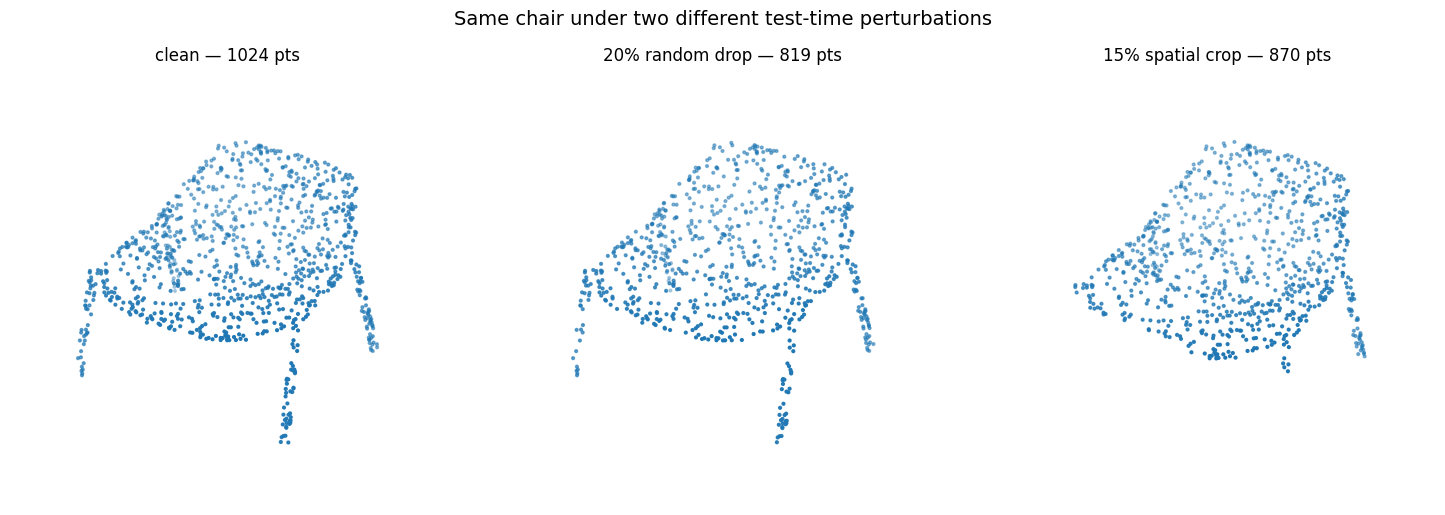

In [15]:
def random_drop(points, drop_ratio=0.2, rng=None):
    """Uniformly remove `drop_ratio` of points, scattered all over the cloud."""
    if rng is None: rng = np.random.default_rng()
    N = points.shape[0]
    keep_n = int(round(N * (1 - drop_ratio)))
    idx = rng.choice(N, keep_n, replace=False)
    return points[idx]


def spatial_crop(points, crop_ratio=0.15, rng=None):
    """Remove a contiguous region: project all points onto a random direction,
    drop the points with the largest projection (removes a 'cap' on one side).
    """
    if rng is None: rng = np.random.default_rng()
    N = points.shape[0]
    remove_n = int(round(N * crop_ratio))
    direction = rng.standard_normal(3)
    direction = direction / np.linalg.norm(direction)
    projections = points @ direction
    keep_idx = np.argsort(projections)[: N - remove_n]
    return points[keep_idx]


# Pick a chair, show all three side by side
chair_idx = int(np.where(test_cached.labels == 2)[0][0])
pts_clean = test_cached.points[chair_idx]

rng = np.random.default_rng(42)
pts_dropped = random_drop(pts_clean, drop_ratio=0.20, rng=rng)
pts_cropped = spatial_crop(pts_clean, crop_ratio=0.15, rng=rng)

fig = plt.figure(figsize=(15, 5))
for i, (pts, title) in enumerate([
    (pts_clean,   f"clean — {pts_clean.shape[0]} pts"),
    (pts_dropped, f"20% random drop — {pts_dropped.shape[0]} pts"),
    (pts_cropped, f"15% spatial crop — {pts_cropped.shape[0]} pts"),
]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=4)
    ax.set_title(title)
    ax.set_axis_off()
plt.suptitle("Same chair under two different test-time perturbations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Evaluating v1 under 20% random point drop

TEST 1 — 20% RANDOM POINT DROP

  Clean accuracy        : 0.9174
  20% random drop       : 0.9152   (Δ -0.0022)
  Macro F1              : 0.9103
  Points per test cloud : 819  (was 1024)

Per-class metrics under 20% random drop:
              precision    recall  f1-score   support

     bathtub     0.8000    0.9600    0.8727        50
         bed     0.9659    0.8500    0.9043       100
       chair     0.9900    0.9900    0.9900       100
        desk     0.9231    0.8372    0.8780        86
     dresser     0.8235    0.8140    0.8187        86
     monitor     1.0000    0.9600    0.9796       100
 night_stand     0.7553    0.8256    0.7889        86
        sofa     1.0000    0.9800    0.9899       100
       table     0.8482    0.9500    0.8962       100
      toilet     1.0000    0.9700    0.9848       100

    accuracy                         0.9152       908
   macro avg     0.9106    0.9137    0.9103       908
weighted avg     0.9202    0.9152    0.9162       908

Class covera

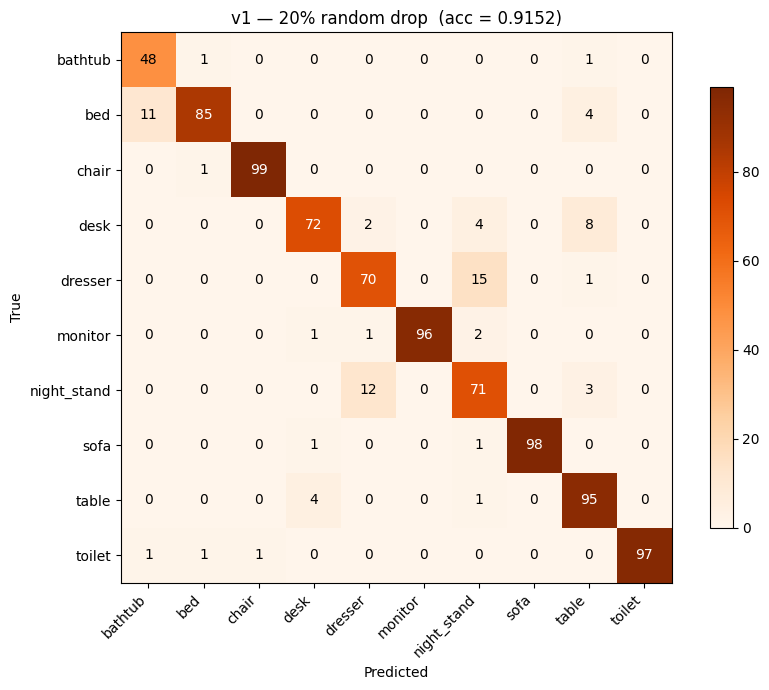

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Load v1 baseline
model = PointNetV1(num_classes=10).to(device)
model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
model.eval()

def evaluate_with_transform(model, cached_ds, transform_fn, transform_kwargs, device, seed=42, batch_size=32):
    """Apply transform_fn to every test sample, run model, return (preds, labels) arrays."""
    rng = np.random.default_rng(seed)
    all_preds, all_labels = [], []
    n = len(cached_ds)
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            batch_pts, batch_lbls = [], []
            for i in range(start, end):
                pts_t = transform_fn(cached_ds.points[i], rng=rng, **transform_kwargs)
                batch_pts.append(pts_t)
                batch_lbls.append(int(cached_ds.labels[i]))
            batch_tensor = torch.from_numpy(np.stack(batch_pts).astype(np.float32)).to(device)
            preds = model(batch_tensor).argmax(1).cpu().numpy()
            all_preds.append(preds)
            all_labels.extend(batch_lbls)
    return np.concatenate(all_preds), np.array(all_labels)


print("=" * 60)
print("TEST 1 — 20% RANDOM POINT DROP")
print("=" * 60)

preds_drop, labels_drop = evaluate_with_transform(
    model, test_cached, random_drop, {"drop_ratio": 0.20}, device, seed=42
)
acc_drop      = accuracy_score(labels_drop, preds_drop)
macro_f1_drop = f1_score(labels_drop, preds_drop, average="macro")

print(f"\n  Clean accuracy        : 0.9174")
print(f"  20% random drop       : {acc_drop:.4f}   (Δ {acc_drop - 0.9174:+.4f})")
print(f"  Macro F1              : {macro_f1_drop:.4f}")
print(f"  Points per test cloud : {int(1024 * 0.8)}  (was 1024)")
print(f"\nPer-class metrics under 20% random drop:")
print(classification_report(labels_drop, preds_drop, target_names=CLASSES, digits=4))
print(f"Class coverage under random drop: {len(set(preds_drop.tolist()))}/10")

cm = confusion_matrix(labels_drop, preds_drop, labels=list(range(10)))
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Oranges")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"v1 — 20% random drop  (acc = {acc_drop:.4f})")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

## Evaluating v1 under 15% spatial crop

TEST 2 — 15% SPATIAL CROP

  Clean accuracy        : 0.9174
  15% spatial crop      : 0.8833   (Δ -0.0341)
  Macro F1              : 0.8795
  Points per test cloud : 870  (was 1024)

Per-class metrics under 15% spatial crop:
              precision    recall  f1-score   support

     bathtub     0.7903    0.9800    0.8750        50
         bed     0.9630    0.7800    0.8619       100
       chair     0.9608    0.9800    0.9703       100
        desk     0.8333    0.8140    0.8235        86
     dresser     0.8072    0.7791    0.7929        86
     monitor     0.9891    0.9100    0.9479       100
 night_stand     0.7473    0.7907    0.7684        86
        sofa     0.9694    0.9500    0.9596       100
       table     0.8000    0.9200    0.8558       100
      toilet     0.9400    0.9400    0.9400       100

    accuracy                         0.8833       908
   macro avg     0.8800    0.8844    0.8795       908
weighted avg     0.8889    0.8833    0.8837       908

Class coverage u

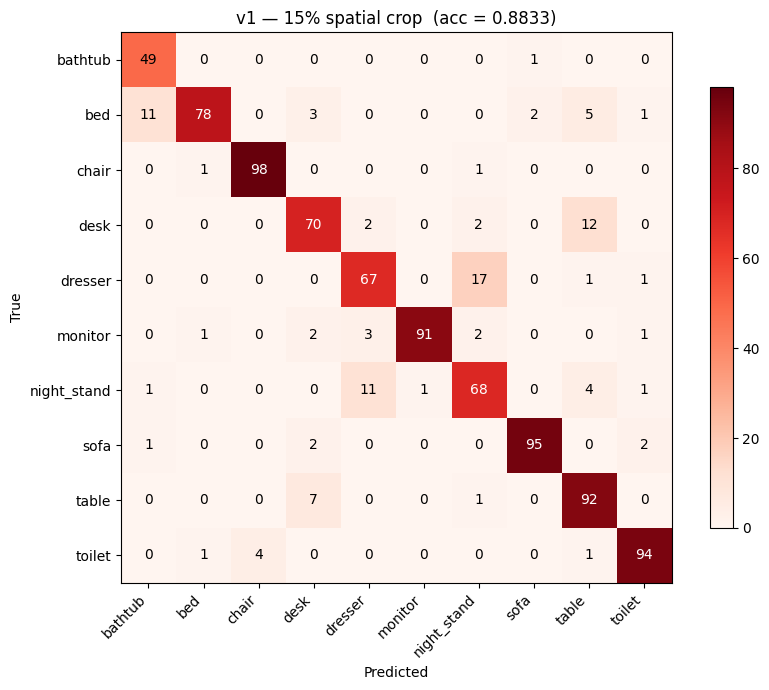


ROBUSTNESS SUMMARY — PointNet v1 (no retraining)
Condition                     Accuracy   Macro F1     Δ acc
------------------------------------------------------------
Clean (1024 points)             0.9174     0.9125         —
20% random drop  (820 pts)      0.9152     0.9103   -0.0022
15% spatial crop (870 pts)      0.8833     0.8795   -0.0341


In [17]:
print("=" * 60)
print("TEST 2 — 15% SPATIAL CROP")
print("=" * 60)

preds_crop, labels_crop = evaluate_with_transform(
    model, test_cached, spatial_crop, {"crop_ratio": 0.15}, device, seed=42
)
acc_crop      = accuracy_score(labels_crop, preds_crop)
macro_f1_crop = f1_score(labels_crop, preds_crop, average="macro")

print(f"\n  Clean accuracy        : 0.9174")
print(f"  15% spatial crop      : {acc_crop:.4f}   (Δ {acc_crop - 0.9174:+.4f})")
print(f"  Macro F1              : {macro_f1_crop:.4f}")
print(f"  Points per test cloud : {int(1024 * 0.85)}  (was 1024)")
print(f"\nPer-class metrics under 15% spatial crop:")
print(classification_report(labels_crop, preds_crop, target_names=CLASSES, digits=4))
print(f"Class coverage under spatial crop: {len(set(preds_crop.tolist()))}/10")

cm = confusion_matrix(labels_crop, preds_crop, labels=list(range(10)))
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Reds")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"v1 — 15% spatial crop  (acc = {acc_crop:.4f})")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

# ---- Final summary table for the prof ----
print("\n" + "=" * 60)
print("ROBUSTNESS SUMMARY — PointNet v1 (no retraining)")
print("=" * 60)
print(f"{'Condition':<28}{'Accuracy':>10}{'Macro F1':>11}{'Δ acc':>10}")
print("-" * 60)
print(f"{'Clean (1024 points)':<28}{0.9174:>10.4f}{0.9125:>11.4f}{'—':>10}")
print(f"{'20% random drop  (820 pts)':<28}{acc_drop:>10.4f}{macro_f1_drop:>11.4f}{acc_drop - 0.9174:>+10.4f}")
print(f"{'15% spatial crop (870 pts)':<28}{acc_crop:>10.4f}{macro_f1_crop:>11.4f}{acc_crop - 0.9174:>+10.4f}")